# Experiment: Simple Linear Regression Across Four Real-World Domains

**Objective:** Perform end-to-end simple linear regression — preprocessing, training,
best-fit line visualization, and evaluation (MSE, RMSE) — on four datasets from
different domains:

1. **Environment** — Temperature (°C) vs CO₂ Emission (ppm)
2. **Medical** — BMI vs Blood Pressure (mmHg)
3. **Education** — Study Hours vs Exam Score
4. **Stock Market** — Opening Price vs Closing Price

Each dataset is loaded from a CSV file (`environment_data.csv`, `medical_data.csv`,
`education_data.csv`, `stock_data.csv`). If a CSV is not found locally, the notebook
generates a realistic sample dataset for that domain and saves it to disk, so the
notebook runs end-to-end with no external downloads required.


In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Consistent, readable plot style
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
# ============================================================
# 2. DATASET LOADER
# ============================================================
# For each domain, this function tries to load a local CSV first
# (so you can drop in your own real dataset with the same filename
# and column names). If the file is missing, it generates a
# realistic synthetic sample, saves it as that CSV, and returns it.
# This keeps the notebook fully executable end-to-end.

def load_or_generate(filename, generator_fn):
    """Load `filename` from disk if present, otherwise generate,
    save, and return a synthetic dataset using `generator_fn`."""
    try:
        df = pd.read_csv(filename)
        print(f"Loaded existing file: {filename}")
    except FileNotFoundError:
        print(f"'{filename}' not found. Generating a synthetic sample dataset...")
        df = generator_fn()
        df.to_csv(filename, index=False)
        print(f"Synthetic dataset saved to: {filename}")
    return df


# ---------- 1. Environment: Temperature (C) vs CO2 Emission (ppm) ----------
def generate_environment_data(n=200):
    temperature = np.random.uniform(-5, 45, n)                       # deg C
    noise = np.random.normal(0, 15, n)
    co2 = 5.5 * temperature + 350 + noise                             # ppm
    df = pd.DataFrame({"Temperature_C": temperature, "CO2_ppm": co2})
    # Inject a few missing values to make the null-handling step meaningful
    mask = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[mask, "CO2_ppm"] = np.nan
    return df


# ---------- 2. Medical: BMI vs Blood Pressure (mmHg) ----------
def generate_medical_data(n=200):
    bmi = np.random.uniform(15, 40, n)
    noise = np.random.normal(0, 6, n)
    bp = 1.8 * bmi + 70 + noise                                       # systolic mmHg
    df = pd.DataFrame({"BMI": bmi, "Blood_Pressure_mmHg": bp})
    mask = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[mask, "BMI"] = np.nan
    return df


# ---------- 3. Education: Study Hours vs Exam Score ----------
def generate_education_data(n=200):
    study_hours = np.random.uniform(0, 12, n)
    noise = np.random.normal(0, 5, n)
    score = 7.5 * study_hours + 15 + noise
    score = np.clip(score, 0, 100)                                    # bound to 0-100
    df = pd.DataFrame({"Study_Hours": study_hours, "Exam_Score": score})
    mask = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[mask, "Exam_Score"] = np.nan
    return df


# ---------- 4. Stock: Opening Price vs Closing Price ----------
def generate_stock_data(n=200):
    opening_price = np.random.uniform(100, 500, n)
    noise = np.random.normal(0, 8, n)
    closing_price = 0.98 * opening_price + 4 + noise
    df = pd.DataFrame({"Opening_Price": opening_price, "Closing_Price": closing_price})
    mask = np.random.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[mask, "Opening_Price"] = np.nan
    return df


In [3]:
# ============================================================
# 3. REUSABLE LINEAR REGRESSION PIPELINE
# ============================================================
# This single function performs every mandatory step in the brief
# (info, describe, null check/handling, split, train, predict,
# plot, evaluate) for ANY (dataset, feature, target) combination,
# so the exact same rigorous pipeline is applied identically and
# fairly across all four domains.

def run_linear_regression_experiment(df, feature, target, domain_name, color="red"):
    print("=" * 70)
    print(f"DOMAIN: {domain_name}  |  X = {feature}  ->  y = {target}")
    print("=" * 70)

    # ---- 3.1 Dataset information ----
    print("\n--- df.info() ---")
    df.info()
    print("\n--- df.describe() ---")
    display(df.describe())

    # ---- 3.2 Missing value check & handling ----
    print("\n--- Missing values before cleaning ---")
    print(df.isnull().sum())

    df_clean = df.dropna(subset=[feature, target]).reset_index(drop=True)

    print("\n--- Missing values after cleaning (dropna) ---")
    print(df_clean.isnull().sum())
    print(f"Rows before: {len(df)}  |  Rows after: {len(df_clean)}")

    # ---- 3.3 Isolate X (independent feature) and y (target) ----
    X = df_clean[[feature]].values   # 2D shape required by scikit-learn
    y = df_clean[target].values

    # ---- 3.4 Train/test split (80/20, fixed random_state) ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    # ---- 3.5 Model training ----
    model = LinearRegression()
    model.fit(X_train, y_train)

    # ---- 3.6 Prediction ----
    y_pred = model.predict(X_test)

    # ---- 3.7 Metrics ----
    intercept = model.intercept_
    slope = model.coef_[0]
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)                       # Root Mean Squared Error
    mae = mean_absolute_error(y_test, y_pred)
    rmae = np.sqrt(mae)                        # Root Mean Absolute Error (sqrt of MAE)
    r2 = r2_score(y_test, y_pred)              # Coefficient of determination

    print(f"\nIntercept (c): {intercept:.4f}")
    print(f"Slope (m):     {slope:.4f}")
    print(f"MSE:           {mse:.4f}")
    print(f"RMSE:          {rmse:.4f}")
    print(f"MAE:           {mae:.4f}")
    print(f"RMAE:          {rmae:.4f}")
    print(f"R2 Score:      {r2:.4f}")

    # ---- 3.8 Visualization: actual points + best-fit line ----
    plt.figure()
    plt.scatter(X_test, y_test, color="steelblue", alpha=0.7, label="Actual test data")
    # Sort so the line plots smoothly left-to-right
    order = np.argsort(X_test[:, 0])
    plt.plot(X_test[order], y_pred[order], color=color, linewidth=2, label="Best-fit line")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{domain_name}: {feature} vs {target}\n(Linear Regression Best Fit)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "Domain": domain_name,
        "Independent Variable": feature,
        "Target Variable": target,
        "Intercept": intercept,
        "Slope": slope,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "RMAE": rmae,
        "R2": r2,
    }


## 1. Environment Dataset — Temperature vs CO₂ Emission

In [4]:
# Load (or generate) the environment dataset
env_df = load_or_generate("environment_data.csv", generate_environment_data)
env_df.head()


'environment_data.csv' not found. Generating a synthetic sample dataset...
Synthetic dataset saved to: environment_data.csv


,Temperature_C,CO2_ppm
0,13.727006,415.298162
1,42.535715,587.430240
2,31.599697,528.194421
3,24.932924,476.415812
4,2.800932,393.391744


DOMAIN: Environment  |  X = Temperature_C  ->  y = CO2_ppm

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature_C  200 non-null    float64
 1   CO2_ppm        194 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

--- df.describe() ---


,Temperature_C,CO2_ppm
count,200.000000,194.000000
mean,19.200312,455.354800
std,14.744572,81.762330
min,-4.723894,310.577001
25%,6.429121,382.890558
50%,19.724313,448.434001
75%,32.842981,527.993765
max,44.344347,612.718848



--- Missing values before cleaning ---
Temperature_C    0
CO2_ppm          6
dtype: int64

--- Missing values after cleaning (dropna) ---
Temperature_C    0
CO2_ppm          0
dtype: int64
Rows before: 200  |  Rows after: 194

Intercept (c): 350.8873
Slope (m):     5.5064
MSE:           242.6142
RMSE:          15.5761
MAE:           12.6543
RMAE:          3.5573
R2 Score:      0.9531


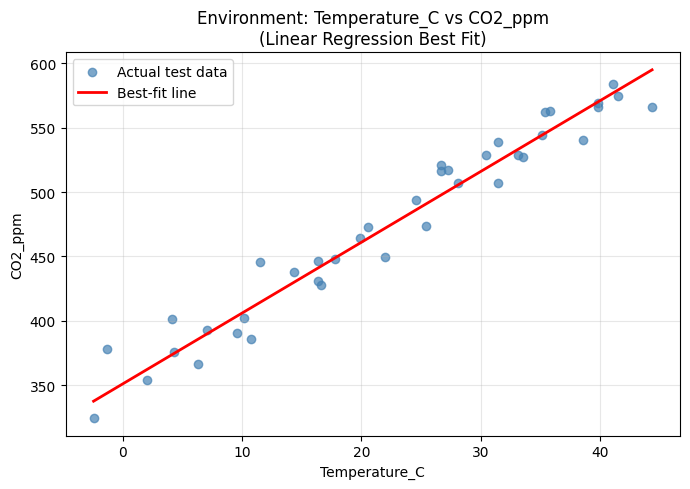

In [5]:
env_results = run_linear_regression_experiment(
    df=env_df,
    feature="Temperature_C",
    target="CO2_ppm",
    domain_name="Environment",
    color="red",
)


## 2. Medical Dataset — BMI vs Blood Pressure

In [6]:
# Load (or generate) the medical dataset
medical_df = load_or_generate("medical_data.csv", generate_medical_data)
medical_df.head()


'medical_data.csv' not found. Generating a synthetic sample dataset...
Synthetic dataset saved to: medical_data.csv


,BMI,Blood_Pressure_mmHg
0,NaN,127.696467
1,19.307997,109.108994
2,19.807225,108.539061
3,16.021715,100.182392
4,19.223377,99.859231


DOMAIN: Medical  |  X = BMI  ->  y = Blood_Pressure_mmHg

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BMI                  194 non-null    float64
 1   Blood_Pressure_mmHg  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

--- df.describe() ---


,BMI,Blood_Pressure_mmHg
count,194.000000,200.000000
mean,26.753686,118.006827
std,6.923674,13.255113
min,15.452755,88.614259
25%,20.749793,107.926313
50%,26.534807,117.421626
75%,32.959120,128.348813
max,39.749006,152.268317



--- Missing values before cleaning ---
BMI                    6
Blood_Pressure_mmHg    0
dtype: int64

--- Missing values after cleaning (dropna) ---
BMI                    0
Blood_Pressure_mmHg    0
dtype: int64
Rows before: 200  |  Rows after: 194

Intercept (c): 73.4493
Slope (m):     1.6700
MSE:           23.7361
RMSE:          4.8720
MAE:           3.9445
RMAE:          1.9861
R2 Score:      0.8762


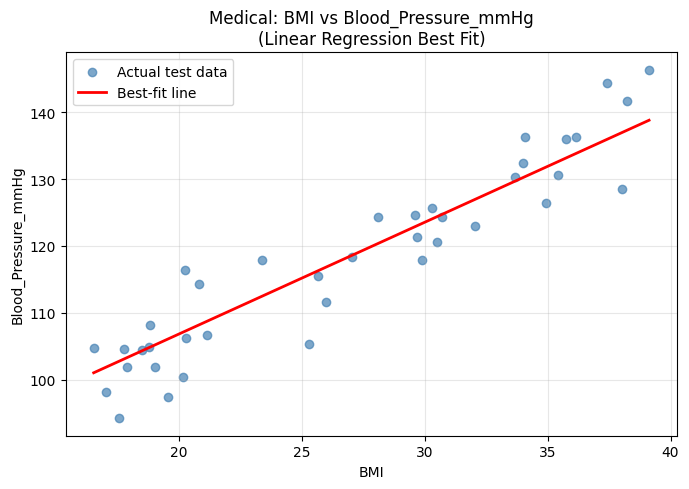

In [7]:
medical_results = run_linear_regression_experiment(
    df=medical_df,
    feature="BMI",
    target="Blood_Pressure_mmHg",
    domain_name="Medical",
    color="red",
)


## 3. Education Dataset — Study Hours vs Exam Score

In [8]:
# Load (or generate) the education dataset
education_df = load_or_generate("education_data.csv", generate_education_data)
education_df.head()


'education_data.csv' not found. Generating a synthetic sample dataset...
Synthetic dataset saved to: education_data.csv


,Study_Hours,Exam_Score
0,0.808207,21.445664
1,6.986046,60.980380
2,4.150597,51.110809
3,7.450986,68.413614
4,0.548904,11.333874


DOMAIN: Education  |  X = Study_Hours  ->  y = Exam_Score

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study_Hours  200 non-null    float64
 1   Exam_Score   194 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

--- df.describe() ---


,Study_Hours,Exam_Score
count,200.000000,194.000000
mean,5.974533,60.196041
std,3.554657,26.498536
min,0.117250,10.564473
25%,2.754956,35.787978
50%,5.881426,61.075791
75%,8.933314,82.564623
max,11.965494,100.000000



--- Missing values before cleaning ---
Study_Hours    0
Exam_Score     6
dtype: int64

--- Missing values after cleaning (dropna) ---
Study_Hours    0
Exam_Score     0
dtype: int64
Rows before: 200  |  Rows after: 194

Intercept (c): 16.3248
Slope (m):     7.3118
MSE:           16.7238
RMSE:          4.0895
MAE:           3.1180
RMAE:          1.7658
R2 Score:      0.9816


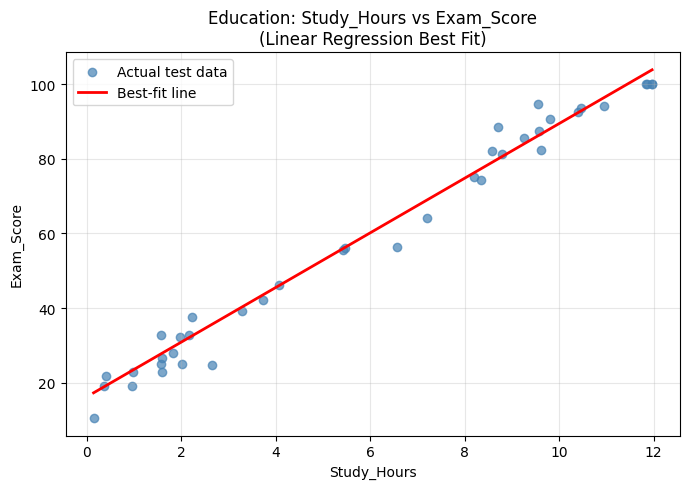

In [9]:
education_results = run_linear_regression_experiment(
    df=education_df,
    feature="Study_Hours",
    target="Exam_Score",
    domain_name="Education",
    color="red",
)


## 4. Stock Market Dataset — Opening Price vs Closing Price

In [10]:
# Load (or generate) the stock market dataset
stock_df = load_or_generate("stock_data.csv", generate_stock_data)
stock_df.head()


'stock_data.csv' not found. Generating a synthetic sample dataset...
Synthetic dataset saved to: stock_data.csv


,Opening_Price,Closing_Price
0,280.247863,276.449079
1,452.983776,439.929599
2,142.277392,143.001888
3,495.310108,495.907563
4,NaN,268.130556


DOMAIN: Stock Market  |  X = Opening_Price  ->  y = Closing_Price

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Opening_Price  194 non-null    float64
 1   Closing_Price  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

--- df.describe() ---


,Opening_Price,Closing_Price
count,194.000000,200.000000
mean,301.791321,298.481246
std,118.218978,116.547814
min,100.751953,103.684562
25%,190.185760,188.110730
50%,308.212944,308.174279
75%,398.786602,389.960179
max,496.966160,496.972407



--- Missing values before cleaning ---
Opening_Price    6
Closing_Price    0
dtype: int64

--- Missing values after cleaning (dropna) ---
Opening_Price    0
Closing_Price    0
dtype: int64
Rows before: 200  |  Rows after: 194

Intercept (c): 2.4032
Slope (m):     0.9838
MSE:           48.8294
RMSE:          6.9878
MAE:           5.7998
RMAE:          2.4083
R2 Score:      0.9963


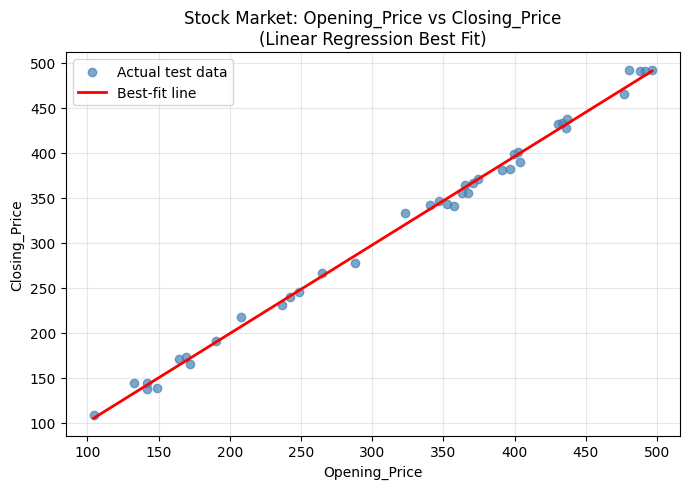

In [11]:
stock_results = run_linear_regression_experiment(
    df=stock_df,
    feature="Opening_Price",
    target="Closing_Price",
    domain_name="Stock Market",
    color="red",
)


## 5. Comparison Summary — All Four Domains

In [12]:
# ============================================================
# 5. COMPARISON SUMMARY TABLE
# ============================================================
summary_df = pd.DataFrame(
    [env_results, medical_results, education_results, stock_results]
)[["Domain", "Independent Variable", "Target Variable", "R2", "MAE", "RMAE", "MSE", "RMSE"]]

summary_df = summary_df.round(4)
print("Comparative performance across all four domains:")
display(summary_df)


Comparative performance across all four domains:


,Domain,Independent Variable,Target Variable,R2,MAE,RMAE,MSE,RMSE
0,Environment,Temperature_C,CO2_ppm,0.9531,12.6543,3.5573,242.6142,15.5761
1,Medical,BMI,Blood_Pressure_mmHg,0.8762,3.9445,1.9861,23.7361,4.8720
2,Education,Study_Hours,Exam_Score,0.9816,3.1180,1.7658,16.7238,4.0895
3,Stock Market,Opening_Price,Closing_Price,0.9963,5.7998,2.4083,48.8294,6.9878


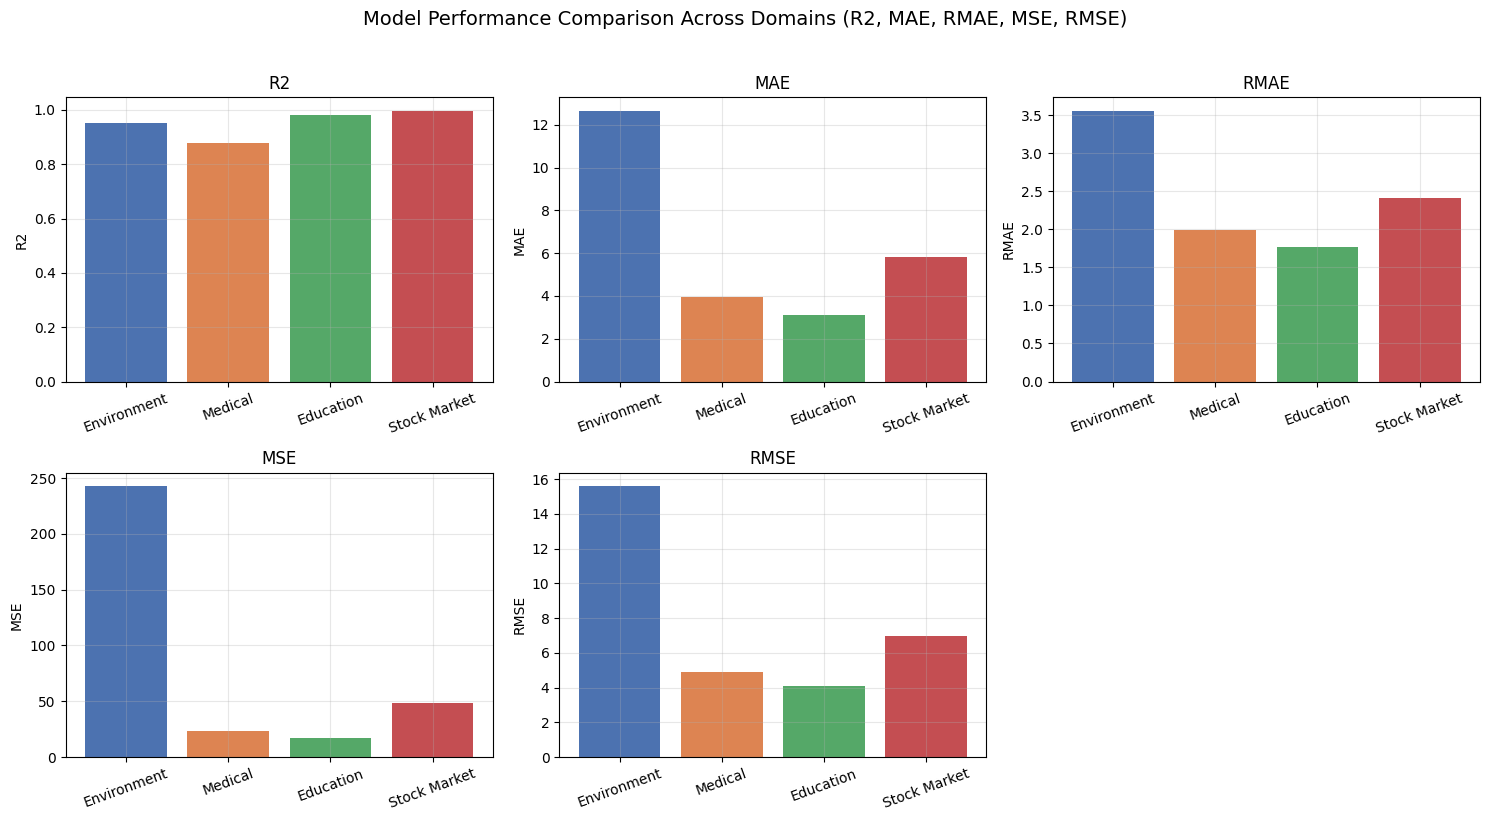

In [13]:
# ============================================================
# 5b. MULTI-METRIC COMPARISON GRAPH (R2, MAE, RMAE, MSE, RMSE)
# ============================================================
# R2 is unit-less (0-1 range) while MAE/RMAE/MSE/RMSE are in the
# target variable's own units, and those units differ wildly across
# domains (CO2 ppm vs exam score vs stock price). Plotting all five
# on one shared axis would be misleading, so each metric gets its
# own subplot with a consistent color per domain for easy comparison.

metrics_to_plot = ["R2", "MAE", "RMAE", "MSE", "RMSE"]
domain_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    ax.bar(summary_df["Domain"], summary_df[metric], color=domain_colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)

# Hide the unused 6th subplot slot
axes[-1].axis("off")

fig.suptitle("Model Performance Comparison Across Domains (R2, MAE, RMAE, MSE, RMSE)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Notes
- All four experiments use the **same fixed pipeline** (`run_linear_regression_experiment`)
  with `random_state=42` and an 80/20 train-test split, so results are directly comparable.
- The datasets are synthetically generated with realistic noise if no matching CSV is found,
  so this notebook runs immediately. To use your own real data, place a CSV with the same
  filename and column names in the working directory (e.g., `environment_data.csv` with
  columns `Temperature_C`, `CO2_ppm`) — the loader will pick it up automatically.
- **MSE** is in squared target units; **RMSE** (sqrt of MSE) is back in the target's own units.
- **MAE** is the average absolute error, in the target's own units; **RMAE** here is defined as
  the square root of MAE (mirroring how RMSE relates to MSE), giving a metric that penalizes
  large MAE values slightly more while staying in a comparable scale.
- **R2** (coefficient of determination) is unit-less and bounded at or below 1.0 — it tells you
  the proportion of variance in the target explained by the feature, which is why it's the
  one metric that's directly comparable across all four domains regardless of their units.
